In [2]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm


# def get_grid_lineset(h_min_val, h_max_val, w_min_val, w_max_val, ignore_axis, grid_length=1, nth_line=5):
#     if (h_min_val%2!=0):
#         h_min_val -= 1
#     if (h_max_val%2!=0):
#         h_max_val += 1
#     if (w_min_val%2!=0):
#         w_min_val -= 1
#     if (w_max_val%2!=0):
#         w_max_val += 1
    
#     num_h_grid = int(np.ceil((h_max_val - h_min_val) / grid_length))
#     num_w_grid = int(np.ceil((w_max_val - w_min_val) / grid_length))
    
#     num_h_grid_mid = num_h_grid // 2
#     num_w_grid_mid = num_w_grid // 2
    
#     grid_vertexes_order = np.zeros((num_h_grid, num_w_grid)).astype(np.int16)
#     grid_vertexes = []
#     vertex_order_index = 0
    
#     for h in range(num_h_grid):
#         for w in range(num_w_grid):
#             grid_vertexes_order[h][w] = vertex_order_index
#             if ignore_axis == 0:
#                 grid_vertexes.append([0, grid_length*w + w_min_val, grid_length*h + h_min_val])
#             elif ignore_axis == 1:
#                 grid_vertexes.append([grid_length*h + h_min_val, 0, grid_length*w + w_min_val])
#             elif ignore_axis == 2:
#                 grid_vertexes.append([grid_length*w + w_min_val, grid_length*h + h_min_val, 0])
#             else:
#                 pass                
#             vertex_order_index += 1       
            
#     next_h = [0, 1]
#     next_w = [1, 0]
#     grid_lines = []
#     grid_nth_lines = []
#     for h in range(num_h_grid):
#         for w in range(num_w_grid):
#             here_h = h
#             here_w = w
#             for i in range(2):
#                 there_h = h + next_h[i]
#                 there_w = w +  next_w[i]   
#                 if (0 <= there_h and there_h < num_h_grid) and (0 <= there_w and there_w < num_w_grid):
#                     if ((here_h % nth_line) == 0) and ((here_w % nth_line) == 0):
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     elif ((here_h % nth_line) != 0) and ((here_w % nth_line) == 0) and i == 1:
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     elif ((here_h % nth_line) == 0) and ((here_w % nth_line) != 0) and i == 0:
#                         grid_nth_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])
#                     else:
#                         grid_lines.append([grid_vertexes_order[here_h][here_w], grid_vertexes_order[there_h][there_w]])

#     color = (0.8, 0.8, 0.8)
#     colors = [color for i in range(len(grid_lines))]
#     line_set = o3d.geometry.LineSet(
#         points=o3d.utility.Vector3dVector(grid_vertexes),
#         lines=o3d.utility.Vector2iVector(grid_lines),
#     )
#     line_set.colors = o3d.utility.Vector3dVector(colors)
    
#     color = (255, 0, 0)
#     colors = [color for i in range(len(grid_nth_lines))]
#     line_nth_set = o3d.geometry.LineSet(
#         points=o3d.utility.Vector3dVector(grid_vertexes),
#         lines=o3d.utility.Vector2iVector(grid_nth_lines),
#     )
#     line_nth_set.colors = o3d.utility.Vector3dVector(colors)
    
#     return line_set, line_nth_set

# def show_open3d_pcd(raw, show_origin=True, origin_size=3, 
#                     show_grid=True, grid_len=1, 
#                     voxel_size=0, 
#                     range_min_xyz=(-80, -80, -80), range_max_xyz=(80, 80, 80)):
#     '''
#     - raw : numpy 2d array (size : (n, 3)) or o3d.geometry.PointCloud
#     - show_origin : show origin XYZ coordinate. (X=red, Y=green, Z=Blue)
#     - origin_size : size of origin coordinate.
#     - show_grid : if true, show grid in xy, yz, zx plane with 'grid_len' length (default : gray line) and 5 times of 'grid_len' (default : red line)
#     - voxel_size : voxel size to downsampling
#     - range_min_xyz : grid min range of xyz orientation
#     - range_max_xyz : grid max range of xyz orientation

#     '''
#     pcd = o3d.geometry.PointCloud()    
    
#     if isinstance(raw, type(pcd)):
#         pcd = raw
#     elif isinstance(raw, np.ndarray):
#         pcd.points = o3d.utility.Vector3dVector(raw)        
#     if voxel_size > 0:
#         pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
        
#     pcd_point = np.array(pcd.points)
#     inrange_inds = (pcd_point[:, 0] > range_min_xyz[0]) & \
#                     (pcd_point[:, 1] > range_min_xyz[1]) & \
#                     (pcd_point[:, 2] > range_min_xyz[2]) & \
#                     (pcd_point[:, 0] < range_max_xyz[0]) & \
#                     (pcd_point[:, 1] < range_max_xyz[1]) & \
#                     (pcd_point[:, 2] < range_max_xyz[2])    
    
#     pcd_point = pcd_point[inrange_inds]
#     filtered_raw = pcd_point
#     pcd.points = o3d.utility.Vector3dVector(filtered_raw)
        
#     x_min_val, y_min_val, z_min_val = range_min_xyz
#     x_max_val, y_max_val, z_max_val = range_max_xyz
    
#     coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=origin_size, origin=np.array([0.0, 0.0, 0.0]))
    
#     ##################################### grid 생성 코드 ######################################
#     lineset_yz, lineset_nth_yz = get_grid_lineset(z_min_val, z_max_val, y_min_val, y_max_val, 0, grid_len)
#     lineset_zx, lineset_nth_zx = get_grid_lineset(x_min_val, x_max_val, z_min_val, z_max_val, 1, grid_len)
#     lineset_xy, lineset_nth_xy = get_grid_lineset(y_min_val, y_max_val, x_min_val, x_max_val, 2, grid_len) 
#     ###########################################################################################
    
#     # set front, lookat, up, zoom to change initial view
#     if show_origin and show_grid:
#         o3d.visualization.draw_geometries([pcd, coord,
#                                            lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
#                                            lineset_xy, lineset_yz, lineset_zx
#                                           ])  
#     elif show_origin and not show_grid:
#         o3d.visualization.draw_geometries([pcd, coord])
#     elif not show_origin and show_grid:
#         o3d.visualization.draw_geometries([pcd,
#                                            lineset_nth_yz, lineset_nth_zx, lineset_nth_xy,
#                                            lineset_xy, lineset_yz, lineset_zx
#                                           ])  
#     else:
#         o3d.visualization.draw_geometries([pcd])  

def pose2d_to_mat4(x, y, yaw):
    """
    2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
    yaw 단위: rad
    """
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.eye(4)
    T[0,0], T[0,1] = c, -s
    T[1,0], T[1,1] = s,  c
    T[0,3], T[1,3] = x, y
    return T

def mat4_to_pose2d(T):
    x, y = T[0,3], T[1,3]
    yaw = np.arctan2(T[1,0], T[0,0])
    return x, y, yaw

def T_w_c_to_T_w_o(T_w_c):
    """
    카메라 좌표계에서 오브젝트 좌표계로 변환
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    """
    # 카메라 좌표계에서 오브젝트 좌표계로의 변환 행렬 (예: 90도 회전)
    T_c_o = np.array([[0, -1, 0, 0],
                      [0, 0, -1, 0],
                      [1, 0, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 계산
    T_w_o = np.dot(T_w_c, T_c_o)
    
    return T_w_o

def T_w_o_to_T_w_c(T_w_o):
    """
    오브젝트 좌표계에서 카메라 좌표계로 변환
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    """
    # 오브젝트 좌표계에서 카메라 좌표계로의 변환 행렬 (예: -90도 회전)
    T_o_c = np.array([[0, 0, 1, 0],
                      [-1, 0, 0, 0],
                      [0, -1, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 카메라 좌표계로의 변환 행렬 계산
    T_w_c = np.dot(T_w_o, T_o_c)
    
    return T_w_c


def project_to_se2_camera(T: np.ndarray) -> np.ndarray:
    """
    임의의 SE(3) 변환 T를 카메라 좌표계(z-forward, x-right, y-down) 기준에서
    (z, x, yaw)만 남기는 4x4로 투영.
    yaw는 y축(수직축) 회전으로 정의.
    """
    # yaw 추출 (y축 회전)
    yaw = np.arctan2(T[0,2], T[2,2])  # R[0,2]/R[2,2]

    c, s = np.cos(yaw), np.sin(yaw)

    Tout = np.eye(4)
    # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
    Tout[0,0], Tout[0,2] =  c, s
    Tout[2,0], Tout[2,2] = -s, c
    Tout[1,1] = 1.0

    # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
    Tout[0,3] = T[0,3]  # x
    Tout[1,3] = 0.0     # y는 무시 (수평 이동만 고려)
    Tout[2,3] = T[2,3]  # z

    return Tout

# def pose2d_to_mat4_cam(x, y, yaw):
#     """
#     2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
#     input x, y, yaw are in body coordinate (x-forward, y-left, z-up)
#     in camera coordinate (z-forward, x-right, y-down)

#     yaw 단위: rad
#     """
#     c, s = np.cos(yaw), np.sin(yaw)

#     Tout = np.eye(4)
#     # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
#     Tout[0,0], Tout[0,2] =  c, -s
#     Tout[2,0], Tout[2,2] = s, c
#     # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
#     Tout[0,3] = -y
#     Tout[2,3] = x
#     return Tout

# def mat4_to_pose2d_cam(T):
#     x, y = T[2,3], -T[0,3]
#     yaw = -np.arctan2(T[0,2], T[2,2])
#     return x, y, yaw

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-09-25 16:28:50,632 - topics - topicmanager initialized


In [3]:
# import copy
# # varify pose2d_to_mat4_cam, mat4_to_pose2d_cam with coordinate of o3d
# x,y,yaw = 1.0, 2.0, np.deg2rad(30)
# T = pose2d_to_mat4_cam(x,y,yaw)
# x2, y2, yaw2 = mat4_to_pose2d_cam(T)
# print(f"input: {x,y,np.rad2deg(yaw)}")
# print(f"output: {x2,y2,np.rad2deg(yaw2)}")
# assert np.isclose(x, x2) and np.isclose(y, y2) and np.isclose(yaw, yaw2)

# coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0]))
# T_w_c = T_w_o_to_T_w_c(np.eye(4))
# coord_cam = copy.deepcopy(coord)
# coord_cam = coord_cam.transform(T_w_c)


# T1 = pose2d_to_mat4(x,y,yaw)
# coord1 = copy.deepcopy(coord_cam)
# coord1 = coord1.transform(T1)
# # translation = T1[0:3, 3]
# # rotation = T1[0:3, 0:3]
# # coord1.translate(translation)
# # coord1.rotate(rotation, center=translation)

# coord.scale(0.5, center=coord.get_center())

# o3d.visualization.draw_geometries([coord, coord_cam, coord1])

# Load rosbag data

In [4]:

# ===============================
# 1. 데이터 로드 (사용자 준비)
# ===============================
# 예시: rgb_list, depth_list, vo_poses는 미리 준비된 리스트
#  - rgb_list: (H, W, 3) numpy array
#  - depth_list: (H, W) numpy array, 사람 영역은 mask된 depth
#  - vo_poses: 각 프레임의 VO pose (4x4 numpy array)

import cv2

rgb_list = [] 
rgb_time = [] 
depth_list = []  
depth_time = [] 
vo_poses = []      # VO trajectory (각각 4x4 pose)
vo_time = []  
object_detect = []  # 각 프레임의 객체 검출 결과 (사용자 정의 형식)
object_time = []  # 객체 검출 시간 리스트
target_pose = []  # 각 프레임의 객체 검출 결과 (3D 좌표)
target_pose_time = []


# for gtsam
poses2d = []  # (x, y, yaw) 리스트
covs2d = []  # 3x3 공분산 리스트



bagfile = "/media/seungwoo/T5_JSW/rosbag_alchemist_2025_08_01/3F/3/2025-08-01-14-40-34.bag"
odom_topic = "/zed2/zed_node/odom"
depth_topic = "/zed_client/image_depth_masked"
rgb_topic = "/zed2/zed_node/rgb/image_rect_color"
obj_det_topic = "/zed2/zed_node/obj_det/objects"
target_pose_topic = "/zed_client/object1_position"


# fig, ax = plt.subplots(1, 1)
# plt.ion()
# ax.set_title("Depth Image")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# img_plot = ax.imshow(np.zeros((480, 640)), cmap='gray')
# colorbar = plt.colorbar(img_plot, ax=ax)
# plt.pause(0.1)  # 잠시 표시

with rosbag.Bag(bagfile) as bag:
    for topic, msg, t in tqdm(bag.read_messages(topics=[rgb_topic, depth_topic, odom_topic, obj_det_topic,target_pose_topic]), desc="Loading data from bag",):
        if topic == rgb_topic:
            rgb = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1).copy()
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb_list.append(rgb)
            rgb_time.append(t)
        elif topic == depth_topic:
            depth = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width).copy()
            # img_plot.set_data(depth)
            # img_plot.set_clim(vmin=np.nanmin(depth), vmax=np.nanmax(depth))
            # plt.pause(0.001)
            depth_list.append(depth)
            depth_time.append(t)
        elif topic == odom_topic:
            
            x = msg.pose.pose.position.x
            y = msg.pose.pose.position.y
            z = 0  # 2D이므로 z=0 고정
            # orientation quaternion -> yaw
            q = msg.pose.pose.orientation
            quat = [q.x, q.y, q.z, q.w]
            roll, pitch, yaw = euler_from_quaternion(quat)
            T = pose2d_to_mat4(x, y, yaw)
            vo_poses.append(T)
            poses2d.append((x, y, yaw))
            cov = np.array(msg.pose.covariance).reshape(6,6)
            cov_2d_cur = cov[np.ix_([0,1,5],[0,1,5])]  # x, y, yaw에 해당하는 부분 추출
            covs2d.append(cov_2d_cur)
            vo_time.append(t)
        elif topic == obj_det_topic:
            object_detect.append(msg)  # 사용자 정의 형식에 맞게 저장
            object_time.append(t)
        elif topic == target_pose_topic:
            object_detect_xyz = np.array([msg.point.x, msg.point.y, msg.point.z], dtype=np.float32)
            target_pose.append(object_detect_xyz)
            target_pose_time.append(t)


# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)
synced_rgb = []
synced_depth = []
synced_vo_poses = []
synced_pose2d = []
synced_cov2d = []
synced_object_detect = []
synced_target_pose = []
for i in range(len(depth_time)):
    depth_t = depth_time[i]
    # 가장 가까운 rgb 찾기
    rgb_diffs = [abs((depth_t - rt).to_sec()) for rt in rgb_time]
    rgb_idx = np.argmin(rgb_diffs)
    # 가장 가까운 vo 찾기
    vo_diffs = [abs((depth_t - vt).to_sec()) for vt in vo_time]
    vo_idx = np.argmin(vo_diffs)
    # 가장 가까운 object detection 찾기
    obj_diffs = []
    for ot in object_time:
        if (depth_t - ot).to_sec() > 0:
            obj_diffs.append(abs((depth_t - ot).to_sec()))
        else:
            obj_diffs.append(float('inf'))
    obj_idx = np.argmin(obj_diffs)
    target_pose_diffs = []
    for tt in target_pose_time:
        if (depth_t - tt).to_sec() > 0:
            target_pose_diffs.append(abs((depth_t - tt).to_sec()))
        else:
            target_pose_diffs.append(float('inf'))
    target_idx = np.argmin(target_pose_diffs)

    # gbr = rgb_list[rgb_idx]
    # rgb = gbr.copy()
    # rgb[:,:,0] = gbr[:,:,2]
    # rgb[:,:,2] = gbr[:,:,0]
    synced_rgb.append(rgb_list[rgb_idx])
    synced_depth.append(depth_list[i])  # depth는 현재 인덱스 사용
    synced_vo_poses.append(vo_poses[vo_idx])
    synced_pose2d.append(poses2d[vo_idx])
    synced_cov2d.append(covs2d[vo_idx])
    synced_object_detect.append(object_detect[obj_idx])
    synced_target_pose.append(target_pose[target_idx])


rgb_list = synced_rgb
depth_list = synced_depth
vo_poses = synced_vo_poses
object_detect = synced_object_detect
poses2d = synced_pose2d
covs2d = synced_cov2d
vo_cam_pose = T_w_o_to_T_w_c(synced_vo_poses)  # 카메라 좌표계에서의 VO pose (4x4 numpy array)
target_pose = synced_target_pose


Loading data from bag: 2006it [00:05, 343.93it/s]


In [5]:

for i in range(len(target_pose)):
    # make relative position to camera
    tar = target_pose[i]
    cur_vo = vo_poses[i]
    tar_cam = np.linalg.inv(cur_vo) @ np.array([tar[0], tar[1], tar[2], 1.0])
    target_pose[i] = tar_cam[:3]


### trim multi man frame

In [6]:
tmp_list = np.array([len(object_detect[i].objects) for i in range(len(object_detect))])

double_man_indxes = np.where(tmp_list>1)[0]
double_man_indxes


array([117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 206, 207, 208, 209, 210, 211, 212, 213, 214,
       217, 222, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244,
       245, 246, 247, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
       304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316,
       317, 318, 319])

In [7]:
tmp_list = [[object_detect[i].objects[j].confidence for j in range(len(object_detect[i].objects))] for i in range(len(object_detect))]
max_conf = []
for tmp in tmp_list:
    if len(tmp)>1:
        max_conf.append(max(tmp))
    else:
        max_conf.append(tmp[0])

tmp_arr = np.array(max_conf)
high_conf_inds = np.where(tmp_arr<70)[0]
high_conf_inds


array([ 85, 264, 265, 266])

In [8]:

for i in double_man_indxes:

    rGlobalMin = 0
    cGlobalMin = 0
    rGlobalMax = 320-1
    cGlobalMax = 640-1
    x_padding = 5
    y_padding = 0
 
    # plt.imshow(depth_list[i])
    # plt.imshow(rgb_list[i])
    for det in object_detect[i].objects:
        # if det.confidence > 70 :
        #     continue
        bound = [det.bounding_box_2d.corners[j].kp for j in range(4)]
        bound = np.array(bound, dtype=int) /2

        rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
        rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
        cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
        cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)
        depth_list[i][rMin:rMax, cMin:cMax] = np.nan
        # plt.plot([cMin, cMax, cMax, cMin, cMin], [rMin, rMin, rMax, rMax, rMin], 'r-')
        # print(det.confidence)
    # plt.show()
    # break
    

### get pcl


In [9]:


# test pcl

index = double_man_indxes[-1]

fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

tmp_rgb_image = rgb_list[index]
rgb = cv2.cvtColor(tmp_rgb_image, cv2.COLOR_RGB2BGR)

rgb_o3d = o3d.geometry.Image(rgb.astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[index].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=5.0,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd.transform(vo_cam_pose[index])  # 카메라 좌표계 → 월드 좌표계

coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coords.transform(vo_cam_pose[index])

o3d.visualization.draw_geometries([prev_pcd, coords])


In [10]:

# visualize first five frames

coords_list = [o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64)) for _ in range(5)]
pcl_list = []
for i in range(5):
    coords_list[i].scale(0.5, center=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    
    coords_list[i].transform(vo_cam_pose[i*20])
    # coords_list[i].transform(vo_poses[i*20])

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.geometry.Image(rgb_list[i*20].astype(np.uint8)),
        o3d.geometry.Image(depth_list[i*20].astype(np.float32)),
        depth_scale = 1.0, depth_trunc=5.0,
        convert_rgb_to_intensity=False
    )

    pcl_list.append(o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic))
    pcl_list[-1].transform(vo_cam_pose[i*20])
    # pcl_list.append(o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic))
    

o3d.visualization.draw_geometries([*coords_list, *pcl_list])


In [11]:
o3d.visualization.draw_geometries([pcl_list[-1]])

In [12]:
# speckle removal
# pcd: o3d.geometry.PointCloud
# 반경 r(m) 안에 최소 nb_points 개의 이웃이 없으면 제거
index = 280

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)
nb_neighbors = 30  # 통계적 이상치 제거 이웃 개수
std_ratio = 0.3  # 통계적 이상치 제거 표준편차 배수

rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.geometry.Image(rgb_list[index].astype(np.uint8)),
        o3d.geometry.Image(depth_list[index].astype(np.float32)),
        depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
pcd.transform(vo_cam_pose[index])

coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coord.transform(vo_cam_pose[index])

pcd_clean, ind_inliers = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)
# pcd_clean, ind_inliers = pcd.remove_radius_outlier(nb_points=16, radius=0.05)

# 필요하면 outlier만 따로 보고 싶다면
# outlier_indices = [i for i in range(len(pcd.points)) if i not in set(ind_inliers)]
# pcd_out = pcd.select_by_index(outlier_indices)

# 시각화 (인라이어=회색, 아웃라이어=빨강)
pcd_vis = pcd_clean.paint_uniform_color([0.7, 0.7, 0.7])
# pcd_out.paint_uniform_color([1.0, 0.0, 0.0])
# o3d.visualization.draw_geometries([pcd_vis, pcd_out])
o3d.visualization.draw_geometries([coord, pcd, pcd_vis])

In [13]:
coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
coords.transform(vo_poses[0])

# o3d.visualization.draw_geometries([prev_pcd, coords])
# show_open3d_pcd(prev_pcd, show_origin=True, origin_size=1, show_grid=True, grid_len=1, voxel_size=0.05,
#                 range_min_xyz=(-10, -10, -2), range_max_xyz=(10, 10, 3))

TriangleMesh with 1134 points and 2240 triangles.

## ICP 

In [14]:
# ===============================
# 2. ICP로 VO trajectory 정제
# ===============================
import copy
visualize = True
start_frame = 0
end_frame = 100
# start_frame = 270
# end_frame = 280
# frame_step = 1  # 몇 프레임마다 처리할지 (속도 조절용)

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)
nb_neighbors = 80  # 통계적 이상치 제거 이웃 개수
std_ratio = 0.05  # 통계적 이상치 제거 표준편차 배수
# yaw_only = True  # 최적화의 yaw만 사용

z_min = -0.5
z_max = 0.5

refined_poses = [vo_cam_pose[start_frame]]
reg_list = []
prev_idx = start_frame

# key_frame_intervals = 1  # 몇 프레임마다 키프레임 갱신할지 (속도 조절용)
# key_frame_indices = [start_frame]
# for kf in range(start_frame + key_frame_intervals, end_frame, key_frame_intervals):
#     key_frame_indices.append(kf)
# if key_frame_indices[-1] != end_frame - 1:
#     key_frame_indices.append(end_frame - 1)
# print("Key frame indices:", key_frame_indices)

if visualize:
    pcl_list = []
    coords_list = []
    pcl_after_list = []
    coords_after_list = []

    t_guess = []
    t_reg = []


# 첫 번째 프레임으로 prev_pcd 초기화
rgb_o3d = o3d.geometry.Image(rgb_list[start_frame].astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[start_frame].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd = prev_pcd.voxel_down_sample(voxel_size)
prev_pcd = prev_pcd.select_by_index(np.where((np.asarray(prev_pcd.points)[:,1] > z_min) & (np.asarray(prev_pcd.points)[:,1] < z_max))[0])
prev_pcd = prev_pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]

if visualize:
    coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    coords.transform(vo_cam_pose[start_frame])

    coords_list.append(coords)
    coords_after_list.append(coords)

    pcl_tmp = copy.deepcopy(prev_pcd)
    pcl_tmp.transform(vo_cam_pose[start_frame]) ##???
    pcl_list.append(pcl_tmp)
    pcl_after_list.append(pcl_tmp)


# prev_pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))


# for i in range(start_frame+frame_step,end_frame, frame_step):
for i in range(start_frame+1,end_frame):
    
    # RGBD 변환
    cur_idx = i
    rgb_o3d   = o3d.geometry.Image(rgb_list[cur_idx].astype(np.uint8))
    depth_o3d = o3d.geometry.Image((depth_list[cur_idx]).astype(np.float32))

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    # print(f"Frame {cur_idx}: Original points = {len(pcd.points)}")
    pcd = pcd.voxel_down_sample(voxel_size)
    pcd = pcd.select_by_index(np.where((np.asarray(pcd.points)[:,1] > z_min) & (np.asarray(pcd.points)[:,1] < z_max))[0])
    pcd = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
    # print(f"Frame {cur_idx}: Downsampled points = {len(pcd.points)}")
    

    if visualize:
        coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord.transform(vo_cam_pose[cur_idx])
        coords_list.append(coord)
        pcl_tmp = copy.deepcopy(pcd)
        pcl_tmp.transform(vo_cam_pose[cur_idx])
        pcl_list.append(pcl_tmp)
    
    
    # Normal vector 계산
    # pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))

    # VO relative transform
    # T_guess = np.linalg.inv(vo_cam_pose[prev_idx]) @ vo_cam_pose[cur_idx]
    # t_guess.append(T_guess)

    
    # if i not in key_frame_indices:
    # ref_ = T_guess # 키프레임이 아니면 VO 추정치 그대로 사용
    # else:
    #     # print(f"Processing frame {i} as keyframe")
    #     # ICP
    #     max_dist = (vo_time[cur_idx] - vo_time[prev_idx]).to_sec() # 1 m/s 이동 가정
    #     # print(max_dist, "m is assumed between frames")
    #     reg = o3d.pipelines.registration.registration_icp(
    #         pcd, prev_pcd,
    #         max_correspondence_distance=max_dist * 1.5,
    #         init=T_guess,
    #         estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPlane()
    #     )

    #     if reg.fitness < 0.85:
    #         print(f"Warning: Low fitness {reg.fitness} at frame {cur_idx}, using VO guess instead")
    #         ref_ = T_guess
    #     else:
    #         # refined pose 업데이트
    #         ref_ = project_to_se2_camera(reg.transformation)
    
        # if yaw_only:
        #     ref_[:3, 3] = T_guess[:3, 3].copy()  # translation은 VO 추정치 사용


    # ref_ = reg.transformation
    # t_reg.append(ref_)
    # T_refined = (refined_poses[-1] @ ref_).copy()
    T_refined = vo_cam_pose[cur_idx]  # 일단 VO trajectory 사용
    refined_poses.append(T_refined)
    # reg_list.append(reg)
    # print(f"Frame {cur_idx}: ICP inlier RMSE = {reg.inlier_rmse}")

    if visualize:
        pcd_tmp = copy.deepcopy(pcd)
        pcd_tmp.transform(T_refined) 
        pcl_after_list.append(pcd_tmp)
        coord_after = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord_after.transform(T_refined)
        coords_after_list.append(coord_after)

    # keyframe 업데이트
    prev_pcd = pcd
    prev_idx = cur_idx

# print("Average residual:", np.mean(residual))

if visualize:
    # visulize results
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list, *pcl_list])
    o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

In [15]:
if visualize:
    # visulize results
    start= 0
    end = len(coords_list)
    
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list[start:end], *pcl_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list[start:end], *pcl_after_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

<Figure size 640x480 with 0 Axes>

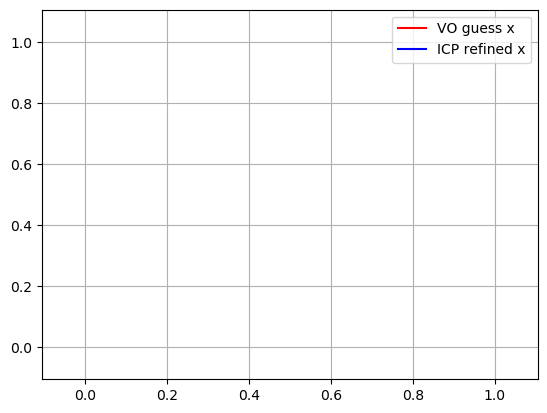

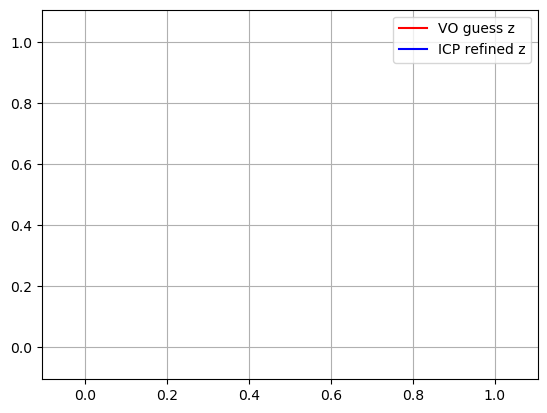

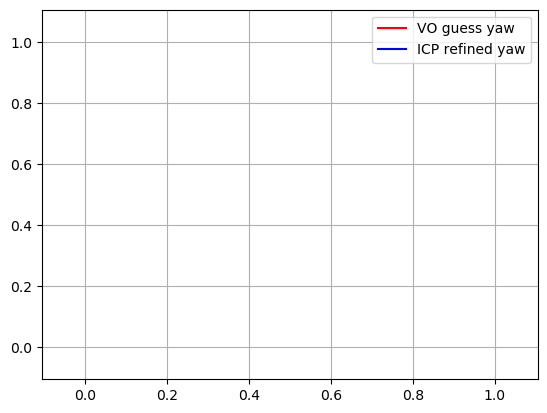

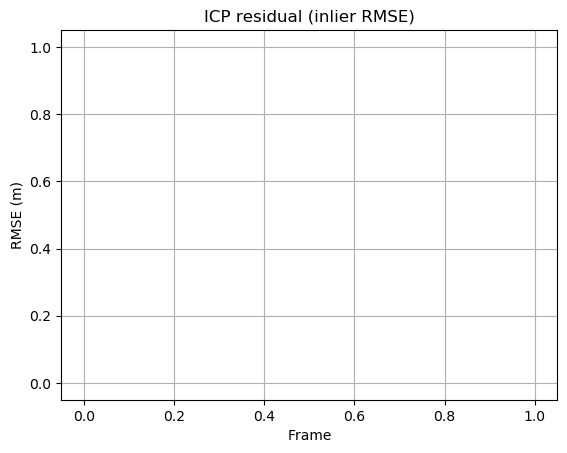

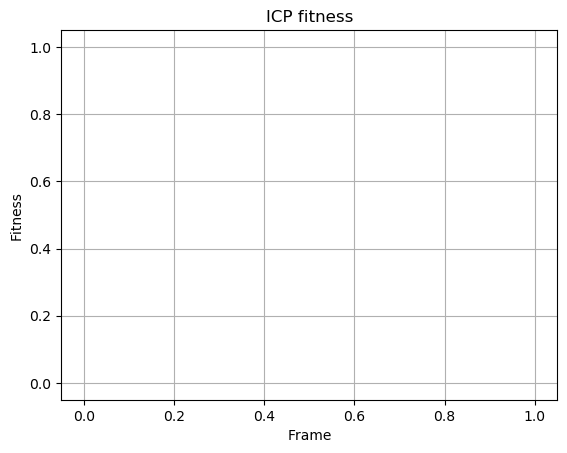

In [16]:
plt.figure()
start = 0
end = len(t_reg)
t_guess_x = [t[0,3] for t in t_guess]
t_guess_y = [t[1,3] for t in t_guess]
t_guess_z = [t[2,3] for t in t_guess]
t_guess_yaw = [np.arctan2(t[0,2], t[2,2]) for t in t_guess]

for i in range(len(t_reg)):
    t_reg[i] = project_to_se2_camera(t_reg[i])

t_reg_x = [t[0,3] for t in t_reg]
t_reg_y = [t[1,3] for t in t_reg]
t_reg_z = [t[2,3] for t in t_reg]
t_reg_yaw = [np.arctan2(t[0,2], t[2,2]) for t in t_reg]

plt.figure()
plt.plot(t_guess_x[start:end], 'r-', label='VO guess x')
plt.plot(t_reg_x[start:end], 'b-', label='ICP refined x')
plt.grid()
plt.legend()

# plt.figure()
# plt.plot(t_guess_y[start:end], 'r-', label='VO guess y')
# plt.plot(t_reg_y[start:end], 'b-', label='ICP refined y')
# plt.grid()
# plt.legend()

plt.figure()
plt.plot(t_guess_z[start:end], 'r-', label='VO guess z')
plt.plot(t_reg_z[start:end], 'b-', label='ICP refined z')
plt.grid()
plt.legend()

plt.figure()
plt.plot(np.rad2deg(t_guess_yaw[start:end]), 'r-', label='VO guess yaw')
plt.plot(np.rad2deg(t_reg_yaw[start:end]), 'b-', label='ICP refined yaw')
plt.grid()
plt.legend()

plt.figure()
plt.plot([reg.inlier_rmse for reg in reg_list], 'k-')
plt.title("ICP residual (inlier RMSE)")
plt.xlabel("Frame")
plt.ylabel("RMSE (m)")
plt.grid()


plt.figure()
plt.plot([reg.fitness for reg in reg_list], 'k-')
plt.title("ICP fitness")
plt.xlabel("Frame")
plt.ylabel("Fitness")
plt.grid()

plt.show()

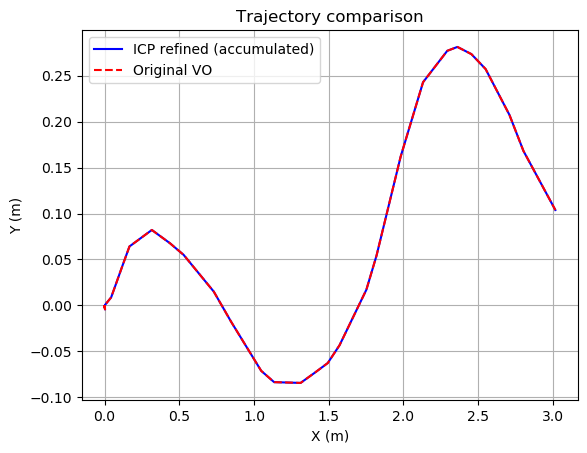

In [17]:

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
original_x = [T[0,3] for T in vo_cam_pose[start_frame:end_frame]]
original_y = [T[1,3] for T in vo_cam_pose[start_frame:end_frame]]
original_yaw = [np.arctan2(T[0,2], T[2,2]) for T in vo_cam_pose[start_frame:end_frame]]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(original_x, original_y, 'r--', label='Original VO')
plt.title("Trajectory comparison")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()


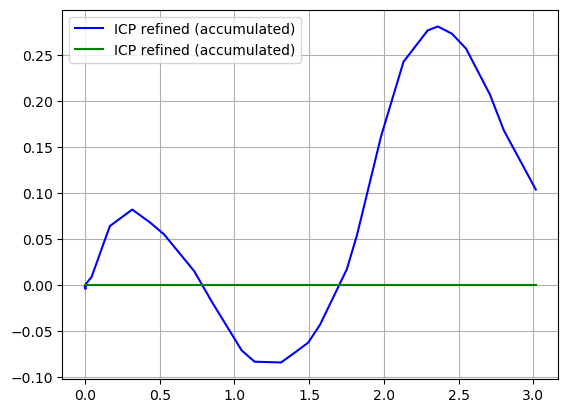

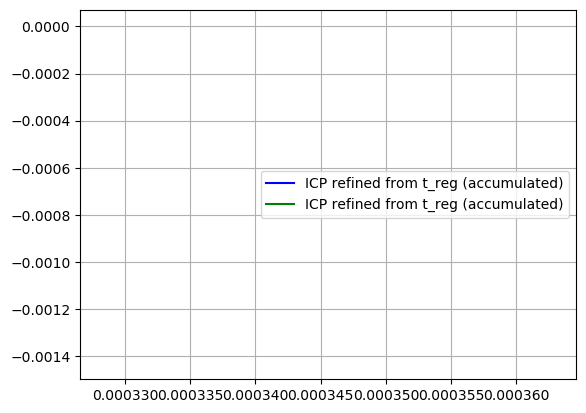

In [18]:
refined_poses_from_t_guess = [vo_cam_pose[0]]
for i in range(len(t_reg)):
    refined_poses_from_t_guess.append(refined_poses_from_t_guess[-1] @ t_guess[i])

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_z = [T[2,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(refined_x, refined_z, 'g-', label='ICP refined (accumulated)')
plt.grid()
plt.legend()

plt.figure()
refined_x2 = [T[0,3] for T in refined_poses_from_t_guess]
refined_y2 = [T[1,3] for T in refined_poses_from_t_guess]
refined_z2 = [T[2,3] for T in refined_poses_from_t_guess]
refined_yaw2 = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses_from_t_guess]
plt.plot(refined_x2, refined_y2, 'b-', label='ICP refined from t_reg (accumulated)')
plt.plot(refined_x2, refined_z2, 'g-', label='ICP refined from t_reg (accumulated)')
plt.grid()
plt.legend()

#### target pose

In [19]:
# # object detection coorditate => x forward, y left, z up (camera coord)
# object_detect_xyz = []
# for i in range(len(object_detect)):
#     if len(object_detect[i].objects) == 1:
#         obj = object_detect[i].objects[0]
#         x = obj.position[0]
#         y = obj.position[1]
#         z = obj.position[2] 
#         object_detect_xyz.append((x,y,z))
#     elif len(object_detect[i].objects) > 1:
#         min_dist = float('inf')
#         x_best, y_best, z_best = None, None, None
#         for obj in object_detect[i].objects:
#             x = obj.position[0]
#             y = obj.position[1]
#             z = obj.position[2]
#             dist = np.hypot(x, y)
#             if dist < min_dist:
#                 min_dist = dist
#                 x_best, y_best, z_best = x, y, z
#         object_detect_xyz.append((x_best, y_best, z_best))
#     else:
#         raise ValueError("No object detected in frame {i}")

In [20]:
# object_detect_xyz = np.array(object_detect_xyz)

# plt.figure()
# plt.scatter(object_detect_xyz[:, 0], object_detect_xyz[:, 1], c='r', label='Object Detections')
# plt.show()

In [21]:
# # sphere in o3d 
# test_index = 600
# target_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.1)
# target_sphere.paint_uniform_color([1.0, 0.0, 0.0])
# P_c_t = [-object_detect_xyz[test_index][1], -object_detect_xyz[test_index][2], object_detect_xyz[test_index][0]]  # 카메라 좌표계 (Z, -X, -Y)
# P_w_t = refined_poses[test_index] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
# target_sphere.translate((P_w_t[0], P_w_t[1], P_w_t[2]))

# o3d.visualization.draw_geometries([pcl_after_list[test_index], target_sphere])

In [22]:
# sphere in o3d 
test_index = 300
target_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.1)
target_sphere.paint_uniform_color([1.0, 0.0, 0.0])
P_c_t = [-target_pose[test_index][1], -target_pose[test_index][2], target_pose[test_index][0]]  # 카메라 좌표계 (Z, -X, -Y)
P_w_t = refined_poses[test_index] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
target_sphere.translate((P_w_t[0], P_w_t[1], P_w_t[2]))

o3d.visualization.draw_geometries([pcl_after_list[test_index], target_sphere])

IndexError: list index out of range

In [ ]:
target_pose_refined = []
for i in range(len(target_pose)):
    P_c_t = [-target_pose[i][1], -target_pose[i][2], target_pose[i][0]]  # 카메라 좌표계 (Z, -X, -Y)
    P_w_t = refined_poses[i] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
    target_pose_refined.append((P_w_t[0], P_w_t[1], P_w_t[2]))


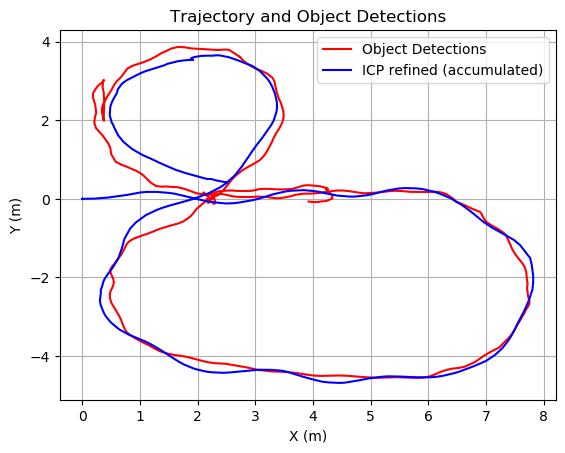

In [ ]:
target_pose_x = [p[0] for p in target_pose_refined]
target_pose_y = [p[1] for p in target_pose_refined]

start = 0
end = len(target_pose_x)

plt.figure()
plt.plot(target_pose_x[start:end], target_pose_y[start:end], 'r-', label='Object Detections')
plt.plot(refined_x[start:end], refined_y[start:end], 'b-', label='ICP refined (accumulated)')
plt.title("Trajectory and Object Detections")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()

## Record as rosbag


## Plotting


In [ ]:
# z cliping
z_low = -0.5
z_high = 0.5

test_pcl = pcl_after_list[500]
points = np.asarray(test_pcl.points)

valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]
clipped_pcl = test_pcl.select_by_index(valid_indices)

o3d.visualization.draw_geometries([clipped_pcl])

In [ ]:

## FINAL PLOT ##

########## PCL ###########
z_low = -0.5
z_high = 0.5

dist_max = 3.0
pcl_2d = []


for i in range(70, len(refined_poses)):
    pcl = pcl_after_list[i]
    cur_pose = refined_poses[i]

    points = np.asarray(pcl.points)
    valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]

    valid_indices2 = np.where(np.hypot(cur_pose[0, 3] - points[:,0], cur_pose[1, 3] - points[:,1]) <= dist_max)[0]
    valid_indices = np.intersect1d(valid_indices, valid_indices2)
    
    clipped_pcl = pcl.select_by_index(valid_indices)
    points = np.asarray(clipped_pcl.points)

    pcl_2d.append(points.copy())

pcl_2d = np.vstack(pcl_2d)

########## target, agent traj ###########
start = 50
end = len(refined_poses)


refined_x = [T[0,3] for T in refined_poses[start:end]]
refined_y = [T[1,3] for T in refined_poses[start:end]]

target_pose_x = [p[0] for p in target_pose_refined[start:end]]
target_pose_y = [p[1] for p in target_pose_refined[start:end]]

# smoothing
from scipy.ndimage import gaussian_filter1d
refined_x = gaussian_filter1d(refined_x, sigma=2)
refined_y = gaussian_filter1d(refined_y, sigma=2)

target_pose_x = gaussian_filter1d(target_pose_x, sigma=2)
target_pose_y = gaussian_filter1d(target_pose_y, sigma=2)

########## rotate for better view
angle = np.deg2rad(-30)
cos_a = np.cos(angle)
sin_a = np.sin(angle)
refined_x_rot = cos_a * np.array(refined_x) - sin_a * np.array(refined_y)
refined_y_rot = sin_a * np.array(refined_x) + cos_a * np.array(refined_y)
refined_x = refined_x_rot
refined_y = refined_y_rot
target_pose_x_rot = cos_a * np.array(target_pose_x) - sin_a * np.array(target_pose_y)
target_pose_y_rot = sin_a * np.array(target_pose_x) + cos_a * np.array(target_pose_y)
target_pose_x = target_pose_x_rot
target_pose_y = target_pose_y_rot
pcl_2d_rot = np.zeros_like(pcl_2d)
pcl_2d_rot[:,0] = cos_a * pcl_2d[:,0] - sin_a * pcl_2d[:,1]
pcl_2d_rot[:,1] = sin_a * pcl_2d[:,0] + cos_a * pcl_2d[:,1]
pcl_2d_rot[:,2] = pcl_2d[:,2]
pcl_2d = pcl_2d_rot.copy()

############# FINAL PLOT #############

plt.figure(figsize=(10, 3))
plt.axis('equal')
# plt.xlim(-5, 5)
plt.ylim(-8, 4)
plt.grid()

plt.plot(refined_x, refined_y, 'b-', label='ICP refined')
plt.plot(target_pose_x, target_pose_y, 'r-', markersize=2, label='Object Detections')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c='gray', alpha=0.5)

# indicate start and end
plt.plot(refined_x[0], refined_y[0], 'bo', markersize=5)
plt.plot(refined_x[-1], refined_y[-1], 'bo', markersize=5)

plt.plot(target_pose_x[0], target_pose_y[0], 'ro', markersize=5)
plt.plot(target_pose_x[-1], target_pose_y[-1], 'ro', markersize=5)

# plot arrow for direction
arrow_interval = 150
for i in range(0, len(refined_x), arrow_interval):
    if i + 1 < len(refined_x):
        dir = np.array([refined_x[i+3]-refined_x[i], refined_y[i+3]-refined_y[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
                     angles='xy', scale_units='xy', scale=1, color='b', width=0.01, headwidth=0.01, headlength=0.1)
for i in range(0, len(target_pose_x), arrow_interval):
    if i + 1 < len(target_pose_x):
        dir = np.array([target_pose_x[i+3]-target_pose_x[i], target_pose_y[i+3]-target_pose_y[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(target_pose_x[i], target_pose_y[i], dir[0], dir[1],
                     angles='xy', scale_units='xy', scale=1, color='r', width=0.01, headwidth=0.01, headlength=0.1)

plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()


NameError: name 'refined_poses' is not defined

### save as rosbag

## icp with gtsam (TBD)

In [ ]:
import gtsam
import gtsam.utils.plot as gtsam_plot
import matplotlib.pyplot as plt

In [ ]:
def o3d_relative_icp_and_info(pcd_j, pcd_i, T_init, use_point_to_plane, max_corr_dist):
    """
    pcd_j를 pcd_i로 정합(즉, i 기준에서 j의 상대변환 추정).
    T_init: 초기값 (i->j 상대변환 추정치)
    return: T_ij (4x4), info6 (6x6)  # Open3D 좌표계 기준
    """
    if use_point_to_plane:
        est = o3d.pipelines.registration.TransformationEstimationPointToPlane()
    else:
        est = o3d.pipelines.registration.TransformationEstimationPointToPoint()

    reg = o3d.pipelines.registration.registration_icp(
        pcd_j, pcd_i,
        max_correspondence_distance=max_corr_dist,
        init=T_init,
        estimation_method=est
    )
    T_ij = reg.transformation

    info6 = o3d.pipelines.registration.get_information_matrix_from_point_clouds(
        pcd_j, pcd_i, max_corr_dist, T_ij
    )  # 6x6 정보행렬 (SE3)

    return T_ij, info6

def info6_to_info2(info6):
    """
    Open3D가 주는 6x6( x y z roll pitch yaw ) 정보행렬에서
    2D( x y yaw ) block만 추출 (인덱스 [0,1,5]).
    """
    idx = [0, 1, 5]
    info2 = info6[np.ix_(idx, idx)]
    return info2

In [ ]:
fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)
pcl_list = []
depth_trunc = 5.0  # 사용할 depth 범위 (m)

for i in range(len(rgb_list)):
    rgb_o3d = o3d.geometry.Image(rgb_list[i].astype(np.uint8))
    depth_o3d = o3d.geometry.Image(depth_list[i].astype(np.float32))
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    pcd = pcd.voxel_down_sample(0.05)
    pcd = pcd.remove_statistical_outlier(nb_neighbors=10,std_ratio=1.0)[0]
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    pcl_list.append(pcd)
print(f"Loaded {len(pcl_list)} point clouds.")

Loaded 654 point clouds.


In [ ]:

graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
Pose2 = gtsam.Pose2

# 0번 prior (아주 강하게 고정)
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6, 1e-6, 1e-6]))
x0, y0, yaw0 = poses2d[0]
graph.add(gtsam.PriorFactorPose2(0, Pose2(x0, y0, yaw0), prior_noise))
initial.insert(0, Pose2(x0, y0, yaw0))

robust_scale  = 1.0    # robust kernel scale (Cauchy/Huber 등)

# 1) VO 에지 추가 (연속 프레임)
for i in range(1, len(poses2d)):
    x1,y1,t1 = poses2d[i-1]
    x2,y2,t2 = poses2d[i]
    dx, dy, dth = x2-x1, y2-y1, (t2 - t1)
    rel = Pose2(dx, dy, dth)

    # 공분산 → 노이즈모델 (VO의 i번째 측정 공분산 사용)
    cov = covs2d[i]
    noise_vo = gtsam.noiseModel.Gaussian.Covariance(cov)

    # (선택) 로버스트 커널로 감싸도 됨
    # noise_vo = gtsam.noiseModel.Robust.Create(
    #     gtsam.noiseModel.mEstimator.Cauchy(robust_scale),
    #     gtsam.noiseModel.Gaussian.Covariance(cov)
    # )

    graph.add(gtsam.BetweenFactorPose2(i-1, i, rel, noise_vo))
    # 초기값은 VO 절대 pose 그대로
    initial.insert(i, Pose2(x2, y2, t2))



In [ ]:

# ----------------------------
# 2) ICP 에지 추가 (keyframe들 사이)
#    - 선택적으로 근접한 이웃 KF에 대해서만 추가 (계산량 절약)
#    - 정보행렬은 Open3D 제공 util로 계산 → 2D block만 사용
# ----------------------------
keyframe_step = 5  # keyframe 간격

keyframes = list(range(0, len(poses2d), keyframe_step))
neighbor_gaps = [1, 10]  # k->k+1, k->k+2 정도만 연결 (loop 비슷한 효과)
for kk, k in enumerate(keyframes):
    Ti = pose2d_to_mat4(*poses2d[k])

    for gap in neighbor_gaps:
        if kk + gap >= len(keyframes):
            continue
        m = keyframes[kk + gap]

        Tj = pose2d_to_mat4(*poses2d[m])

        # 초기 상대추정: VO 기반 (i->j)
        T_ij_init = np.linalg.inv(Ti) @ Tj

        # ICP 정합 + 정보행렬
        time_diff = (vo_time[m] - vo_time[k]).to_sec()
        max_corr_dist = time_diff * 1.5  # 1.5 m
        T_ij_icp, info6 = o3d_relative_icp_and_info(pcl_list[m], pcl_list[k], T_ij_init, use_point_to_plane=True, max_corr_dist=max_corr_dist)
        info2 = info6_to_info2(info6)

        # 정보행렬이 나왔으니 GTSAM noise = Gaussian.Information(info2)
        # (로버스트 커널 권장)
        base_noise = gtsam.noiseModel.Gaussian.Information(info2)
        noise_icp = gtsam.noiseModel.Robust.Create(
            gtsam.noiseModel.mEstimator.Cauchy(robust_scale),
            base_noise
        )

        # ICP 상대변환을 2D로 투영해서 BetweenFactorPose2로 추가
        dx, dy, dth = mat4_to_pose2d(T_ij_icp)
        graph.add(gtsam.BetweenFactorPose2(k, m, gtsam.Pose2(dx, dy, dth), noise_icp))


params = gtsam.LevenbergMarquardtParams()
params.setVerbosityLM("ERROR")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
result = optimizer.optimize()


In [ ]:
poses2d_opt = []
for i in range(len(poses2d)):
    p = result.atPose2(i)
    poses2d_opt.append((p.x(), p.y(), p.theta()))

WARNING - 2025-09-23 02:18:19,595 - legend - No handles with labels found to put in legend.


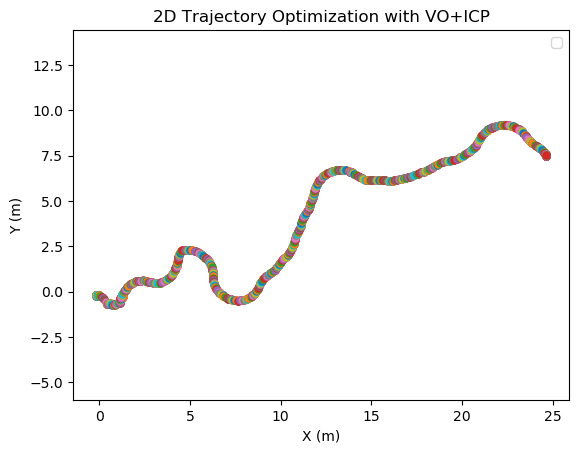

In [ ]:
plt.figure()   
poses2d_array = np.array(poses2d)[:, :2].T

poses2d_opt_array = np.array(poses2d_opt)[:, :2].T

gtsam_plot.plot_point2(fignum=1, point=poses2d_array, linespec='r--')
gtsam_plot.plot_point2(fignum=1, point=poses2d_opt_array, linespec='.')
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis('equal')
plt.legend()
plt.title("2D Trajectory Optimization with VO+ICP")
plt.show()
import numpy as np  
import open3d as o3d
